In [ ]:
# 小型CNN測試 成功。
import tensorflow as tf
from tensorflow.keras import layers, models

print("GPUs:", tf.config.list_physical_devices("GPU"))

model = models.Sequential([
    layers.Conv2D(8, 3, activation="relu", input_shape=(64,64,3)),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(2, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")

import numpy as np
x = np.random.rand(32,64,64,3).astype("float32")
y = np.random.randint(0,2,size=(32,))

model.fit(x,y,epochs=1)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1/1 [==============================] - 3s 3s/step - loss: 0.6686


In [4]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gen = ImageDataGenerator(rescale=1./255)
flow = gen.flow_from_directory(
    r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train",
    target_size=(64,64),
    batch_size=16,
    class_mode="categorical",
    shuffle=True
)

x, y = next(flow)
print("batch x:", x.shape, x.dtype, "y:", y.shape, y.dtype)



TF: 2.10.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 121062 images belonging to 9 classes.
batch x: (16, 64, 64, 3) float32 y: (16, 9) float32


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.
Found 17861 images belonging to 8 classes.
Found 3827 images belonging to 8 classes.
Found 3831 images belonging to 8 classes.
Stage2 num_classes = 8
Stage2 class_indices = {'Center': 0, 'Donut': 1, 'Edge-loc': 2, 'Edge-ring': 3, 'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-Full': 7}

Stage1: None vs Defect
[INFO] Found existing Stage1 weights: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\stage1_greedy_weight_regularcnn_best.h5
Stage1 ready.

Compute class_weight for Stage2 (defect-only, sum=100)

Stage2 class weights (NO None, normalized to sum=100):
-------------------------------------------------------
Center       (class 0): weight =   2.05
Donut        (class 1): weight =  15.92
Edge-loc     (class 2): weight =   1.70
Edge-ring    (class 3): weight =   0.91
Loc        

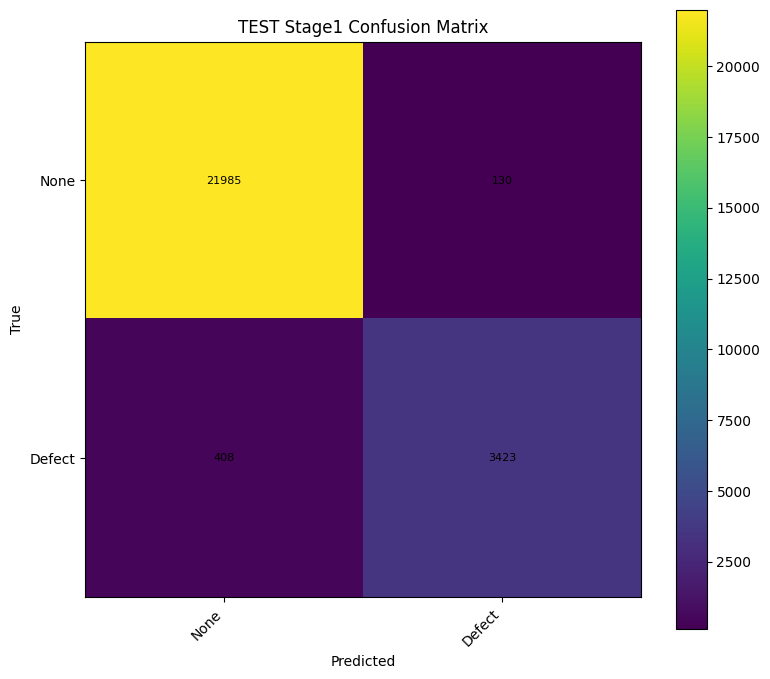


=== TEST Stage2 Report (defect-only) ===
              precision    recall  f1-score   support

      Center     0.9318    0.9503    0.9410       604
       Donut     0.7879    0.9286    0.8525        84
    Edge-loc     0.5406    0.6275    0.5808       647
   Edge-ring     1.0000    0.7615    0.8646      1417
         Loc     0.7351    0.3223    0.4481       422
      Random     0.5918    0.9355    0.7250       124
     Scratch     0.1774    0.8627    0.2943       102
   Near-Full     0.0000    0.0000    0.0000        23

    accuracy                         0.7236      3423
   macro avg     0.5956    0.6735    0.5883      3423
weighted avg     0.8173    0.7236    0.7449      3423



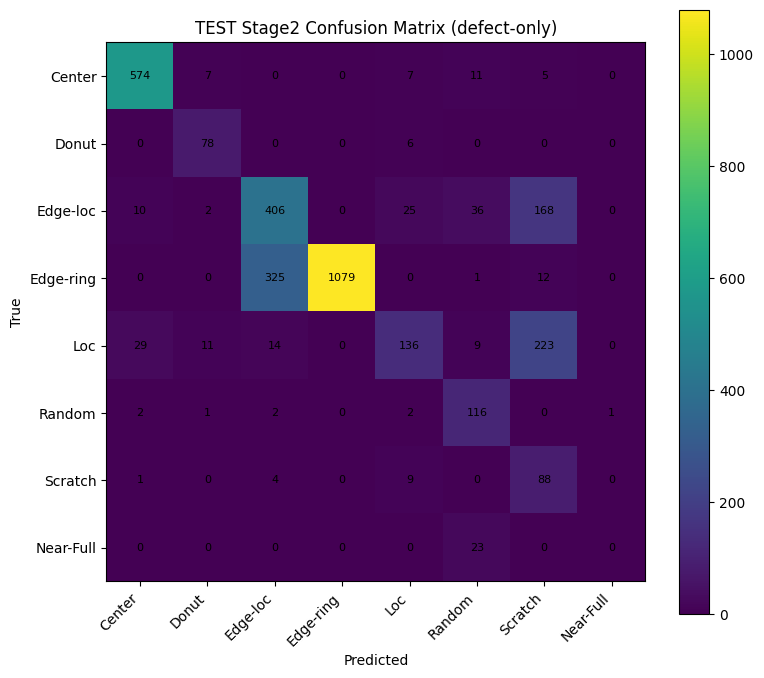


=== TEST Two-Stage Final Report (K+1) ===
              precision    recall  f1-score   support

        None     0.9818    0.9941    0.9879     22115
      Center     0.9318    0.8899    0.9104       645
       Donut     0.7879    0.9286    0.8525        84
    Edge-loc     0.5406    0.5212    0.5307       779
   Edge-ring     1.0000    0.7431    0.8526      1452
         Loc     0.7351    0.2523    0.3757       539
      Random     0.5918    0.8923    0.7117       130
     Scratch     0.1774    0.4916    0.2607       179
   Near-Full     0.0000    0.0000    0.0000        23

   micro avg     0.9476    0.9428    0.9452     25946
   macro avg     0.6385    0.6348    0.6091     25946
weighted avg     0.9542    0.9428    0.9443     25946



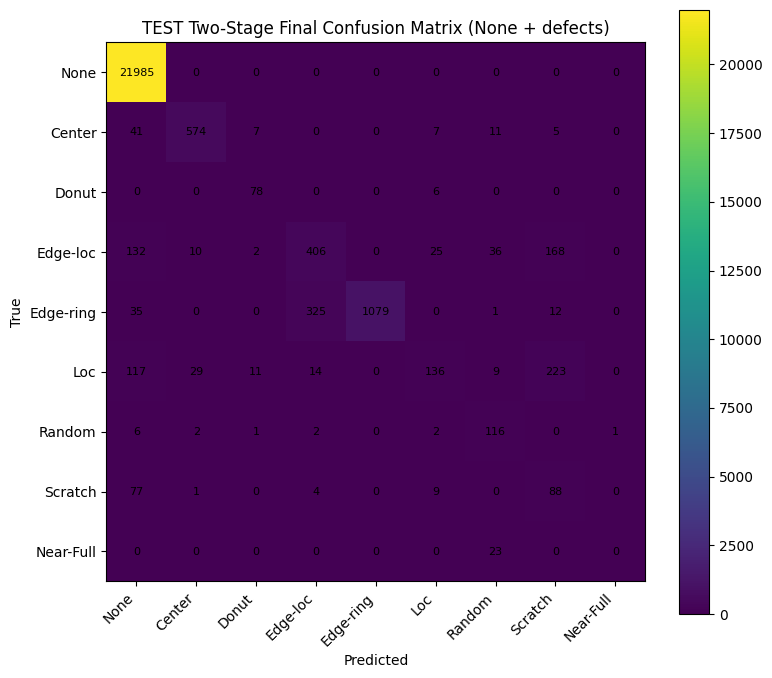


Done.


In [1]:
# =========================================================
# Two-Stage Wafer Classification (TRAIN + TEST) - Stable Version
# ---------------------------------------------------------
# Stage1: Binary classification (Defect vs None)
# Stage2: Multiclass defect-only classification (8 classes)
# Optional: Greedy search for defect-only augmentation pipeline
# Outputs: reports + confusion matrices + CSV predictions
# =========================================================

import os
import time
import random
import gc
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageOps

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report


# =========================================================
# 0) Config (EDIT THESE)
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Stability: GPU memory growth
# -----------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("GPUs:", gpus)

IMAGE_SIZE = (64, 64)

# -----------------------------
# Stability: start smaller to avoid OOM / kernel crash
# You can scale it up after it runs end-to-end.
# -----------------------------
BATCH_SIZE = 16  # was 32

DATASET_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

NONE_CLASS_NAME = "None"

CLASS_LIST = [
    "Center","Donut","Edge-loc","Edge-ring","Loc",
    "Random","Scratch","Near-Full","None"
]

DEFECT_CLASS_LIST = [c for c in CLASS_LIST if c != NONE_CLASS_NAME]

STAGE1_weight_H5 = os.path.join(DATASET_DIR, "stage1_greedy_weight_regularcnn_best.h5")
STAGE2_weight_H5 = os.path.join(DATASET_DIR, "stage2_greedy_weight_regularcnn_best.h5")
OUT_TEST_CSV     = os.path.join(DATASET_DIR, "test_greedy_two_stage_predictions.csv")
OUT_GREEDY_CSV   = os.path.join(DATASET_DIR, "greedy_defect_only_results.csv")

EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 15

THRESH_STAGE1 = 0.5

# -----------------------------
# Greedy configs (stabilized)
# -----------------------------
RUN_GREEDY = True
USE_GREEDY_FOR_STAGE2 = True

TRIAL_EPOCHS = 2     # was 3
MAX_ROUNDS   = 2     # was 3
MIN_GAIN     = 0.003

GREEDY_STEPS      = 30   # was 100
GREEDY_VAL_STEPS  = 20   # was 50

CANDIDATES = ["hflip", "vflip", "rot90", "affine", "noise", "erase", "sharpen"]

SEARCH_REPEATS = 2  # was 5
FINAL_REPEATS  = 5  # was 20


# =========================================================
# Utility: Plot confusion matrix
# =========================================================
def plot_cm(cm, labels, title):
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


# =========================================================
# Model builders
# =========================================================
def build_cnn(num_outputs, final_activation, loss_name):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", padding="same",
               input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_outputs, activation=final_activation)
    ])
    model.compile(optimizer="adam", loss=loss_name, metrics=["accuracy"])
    return model


def build_stage2_model_for_greedy(num_outputs):
    m = Sequential([
        Conv2D(32, (3,3), activation="relu", padding="same",
               input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(num_outputs, activation="softmax"),
    ])
    m.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")]
    )
    return m


# =========================================================
# 2) Data flows
# =========================================================
train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_LIST,
    shuffle=True,
    seed=SEED
)

val_flow = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_LIST,
    shuffle=False
)

test_flow = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode="categorical",
    classes=CLASS_LIST,
    shuffle=False
)

assert NONE_CLASS_NAME in train_flow.class_indices, f"'{NONE_CLASS_NAME}' not found in {train_flow.class_indices}"
none_idx = train_flow.class_indices[NONE_CLASS_NAME]

train_def_flow = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,
    shuffle=False,
    seed=SEED
)

val_def_flow = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,
    shuffle=False
)

test_def_flow = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,
    shuffle=False
)

idx_to_name_def = {v: k for k, v in train_def_flow.class_indices.items()}
print("Stage2 num_classes =", train_def_flow.num_classes)
print("Stage2 class_indices =", train_def_flow.class_indices)


# =========================================================
# 3) Stage1 wrapper (binary)
# =========================================================
class BinaryWrapper(Sequence):
    def __init__(self, base_flow, none_index):
        self.base = base_flow
        self.none_index = int(none_index)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        y_cls = np.argmax(y, axis=1)
        y_bin = (y_cls != self.none_index).astype(np.float32).reshape(-1, 1)
        return x, y_bin

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()

train_bin = BinaryWrapper(train_flow, none_idx)
val_bin   = BinaryWrapper(val_flow, none_idx)
test_bin  = BinaryWrapper(test_flow, none_idx)


# =========================================================
# 4) Stage1 training
# =========================================================
print("\n==============================")
print("Stage1: None vs Defect")
print("==============================")

stage1 = build_cnn(
    num_outputs=1,
    final_activation="sigmoid",
    loss_name="binary_crossentropy"
)

if os.path.exists(STAGE1_weight_H5):
    print(f"[INFO] Found existing Stage1 weights: {STAGE1_weight_H5}")
    stage1.load_weights(STAGE1_weight_H5)
else:
    print("[INFO] No existing Stage1 weights. Start training Stage1.")

    cb1 = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(STAGE1_weight_H5, monitor="val_loss", save_best_only=True)
    ]

    stage1.fit(
        train_bin,
        validation_data=val_bin,
        epochs=EPOCHS_STAGE1,
        callbacks=cb1,
        verbose=2,
        workers=0,
        use_multiprocessing=False
    )

print("Stage1 ready.")


# =========================================================
# 5) Compute Stage2 class_weight (defect-only)
# =========================================================
print("\n==============================")
print("Compute class_weight for Stage2 (defect-only, sum=100)")
print("==============================")

labels_def = train_def_flow.classes
classes_present = np.unique(labels_def)

raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=labels_def
)
class_weights_raw = {int(c): float(w) for c, w in zip(classes_present, raw_weights)}

TOTAL_WEIGHT = 100.0
sum_w = sum(class_weights_raw.values())
class_weights_s2 = {k: (v / sum_w) * TOTAL_WEIGHT for k, v in class_weights_raw.items()}

print("\nStage2 class weights (NO None, normalized to sum=100):")
print("-" * 55)
for idx in sorted(class_weights_s2.keys()):
    print(f"{idx_to_name_def[idx]:<12} (class {idx}): weight = {class_weights_s2[idx]:6.2f}")
print("-" * 55)
print(f"SUM = {sum(class_weights_s2.values()):.2f}")


# =========================================================
# 6) Aug ops (PIL)
# =========================================================
def aug_apply_pil(img_pil, op, rng):
    if op == "hflip":
        return ImageOps.mirror(img_pil)
    if op == "vflip":
        return ImageOps.flip(img_pil)
    if op == "rot90":
        ang = rng.choice([90, 180, 270])
        return img_pil.rotate(ang, resample=Image.NEAREST, expand=False)
    if op == "affine":
        w, h = img_pil.size
        scale = rng.uniform(0.90, 1.10)
        tx = rng.uniform(-0.05, 0.05) * w
        ty = rng.uniform(-0.05, 0.05) * h
        a = scale; b = 0; c = tx
        d = 0; e = scale; f = ty
        return img_pil.transform(img_pil.size, Image.AFFINE, (a,b,c,d,e,f), resample=Image.NEAREST)
    if op == "noise":
        x = np.asarray(img_pil).astype(np.float32)
        sigma = rng.uniform(3.0, 10.0)
        n = rng.normal(0, sigma, size=x.shape).astype(np.float32)
        x2 = np.clip(x + n, 0, 255).astype(np.uint8)
        return Image.fromarray(x2)
    if op == "erase":
        x = np.asarray(img_pil).copy()
        h, w = x.shape[0], x.shape[1]
        rw = int(rng.uniform(0.15, 0.35) * w)
        rh = int(rng.uniform(0.15, 0.35) * h)
        x0 = int(rng.uniform(0, max(1, w - rw)))
        y0 = int(rng.uniform(0, max(1, h - rh)))
        val = int(rng.uniform(0, 255))
        x[y0:y0+rh, x0:x0+rw, :] = val
        return Image.fromarray(x)
    if op == "sharpen":
        enhancer = ImageEnhance.Sharpness(img_pil)
        factor = rng.uniform(0.5, 2.0)
        return enhancer.enhance(factor)
    return img_pil


# =========================================================
# 6) Greedy defect-only augmentation selection (stable)
# =========================================================
class GreedyDefectAugSequence(tf.keras.utils.Sequence):
    def __init__(self, base_uint8_flow, pipeline, image_size, seed=42, apply_prob=0.7):
        self.base = base_uint8_flow
        self.pipeline = list(pipeline)
        self.image_size = tuple(image_size)
        self.seed = int(seed)
        self.apply_prob = float(apply_prob)

        pipe_sig = "|".join(self.pipeline).encode("utf-8")
        self.pipe_hash = zlib.crc32(pipe_sig) & 0xFFFFFFFF

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_u8, y = self.base[idx]
        out_imgs = []
        for j in range(x_u8.shape[0]):
            s = (self.seed * 1000003 + idx * 1009 + j * 9176 + self.pipe_hash) & 0xFFFFFFFF
            rng = np.random.default_rng(s)

            img = np.clip(x_u8[j], 0, 255).astype(np.uint8)
            pil = Image.fromarray(img).convert("RGB")

            for op in self.pipeline:
                if rng.random() < self.apply_prob:
                    pil = aug_apply_pil(pil, op, rng)

            pil = pil.resize(self.image_size, Image.NEAREST)
            x01 = np.asarray(pil).astype(np.float32) / 255.0
            out_imgs.append(x01)

        X = np.stack(out_imgs, axis=0)
        return X, y

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()


GREEDY_SELECTED = []

if RUN_GREEDY:
    print("\n==============================")
    print("Greedy (defect-only) Augmentation Selection")
    print("==============================")

    train_def_uint8_greedy = ImageDataGenerator().flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,
        shuffle=False,
        seed=SEED
    )

    val_def_flow_greedy = ImageDataGenerator(rescale=1./255).flow_from_directory(
        VAL_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,
        shuffle=False
    )

    num_def_classes = len(DEFECT_CLASS_LIST)

    def run_trial(pipeline, trial_seed):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(int(trial_seed))

        if hasattr(train_def_uint8_greedy, "reset"):
            train_def_uint8_greedy.reset()
        if hasattr(val_def_flow_greedy, "reset"):
            val_def_flow_greedy.reset()

        train_aug = GreedyDefectAugSequence(
            train_def_uint8_greedy, pipeline, IMAGE_SIZE, seed=trial_seed
        )

        model = build_stage2_model_for_greedy(num_outputs=num_def_classes)

        es = EarlyStopping(monitor="val_loss", patience=2, mode="min", restore_best_weights=True)

        steps = min(len(train_aug), GREEDY_STEPS)
        val_steps = min(len(val_def_flow_greedy), GREEDY_VAL_STEPS)

        t0 = time.time()
        model.fit(
            train_aug,
            validation_data=val_def_flow_greedy,
            epochs=TRIAL_EPOCHS,
            steps_per_epoch=steps,
            validation_steps=val_steps,
            verbose=0,
            callbacks=[es],
            class_weight=class_weights_s2,
            workers=0,
            use_multiprocessing=False
        )
        elapsed = time.time() - t0

        val_def_flow_greedy.reset()
        eval_out = model.evaluate(val_def_flow_greedy, steps=val_steps, verbose=0)

        metrics_names = model.metrics_names
        loss_val = float(eval_out[0])

        if "acc" in metrics_names:
            acc_val = float(eval_out[metrics_names.index("acc")])
        elif "accuracy" in metrics_names:
            acc_val = float(eval_out[metrics_names.index("accuracy")])
        else:
            acc_val = float(eval_out[1])

        # aggressive cleanup (important for notebook stability)
        del model
        tf.keras.backend.clear_session()
        gc.collect()

        return acc_val, loss_val, elapsed

    def run_trial_avg(pipeline, repeats):
        accs, losses, times_ = [], [], []
        for r in range(repeats):
            seed = SEED + 1000 * r
            a, l, t = run_trial(pipeline, seed)
            accs.append(a)
            losses.append(l)
            times_.append(t)

        # ddof=1 requires >=2 samples; safeguard
        std_acc = float(np.std(accs, ddof=1)) if len(accs) >= 2 else 0.0
        std_loss = float(np.std(losses, ddof=1)) if len(losses) >= 2 else 0.0

        return (float(np.mean(accs)), std_acc,
                float(np.mean(losses)), std_loss,
                float(np.sum(times_)))

    selected = []
    remaining = list(CANDIDATES)

    base_acc, base_std, _, _, _ = run_trial_avg([], SEARCH_REPEATS)
    best_acc = base_acc
    print(f"[BASE] pipeline=[] acc={base_acc:.4f}±{base_std:.4f}")

    for rnd in range(1, MAX_ROUNDS + 1):
        print(f"\n===== Round {rnd} =====")
        results = []
        for cand in remaining:
            pipe = selected + [cand]
            acc_m, acc_s, loss_m, loss_s, _ = run_trial_avg(pipe, SEARCH_REPEATS)
            gain = acc_m - best_acc
            print(f"{pipe}  acc={acc_m:.4f}±{acc_s:.4f}  loss={loss_m:.4f}±{loss_s:.4f}  gain={gain:+.4f}")
            results.append((cand, acc_m, loss_m, acc_s))

        results.sort(key=lambda x: (-x[1], x[2], x[3]))
        best_cand, cand_acc, _, _ = results[0]

        if cand_acc - best_acc < MIN_GAIN:
            print("[STOP] gain < MIN_GAIN")
            break

        selected.append(best_cand)
        remaining.remove(best_cand)
        best_acc = cand_acc
        print("[SELECT]", best_cand, "-> best_acc =", best_acc)

    GREEDY_SELECTED = selected
    print("\nFINAL SELECTED PIPELINE:", GREEDY_SELECTED)

    print("\n[Final Robust Evaluation]")
    acc_m, acc_s, loss_m, loss_s, _ = run_trial_avg(GREEDY_SELECTED, FINAL_REPEATS)
    print(f"Final pipeline acc={acc_m:.4f}±{acc_s:.4f}  loss={loss_m:.4f}±{loss_s:.4f}")


# =========================================================
# 7) Stage2 training (defect-only)
# =========================================================
print("\n==============================")
print("Train Stage2: defect-only multiclass (with class_weight)")
print("==============================")

stage2 = build_cnn(
    num_outputs=train_def_flow.num_classes,
    final_activation="softmax",
    loss_name="categorical_crossentropy"
)

cb2 = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(STAGE2_weight_H5, monitor="val_loss", save_best_only=True)
]


class DefectOnlyAugSequenceV2(Sequence):
    """
    Stage2 TRAINING sequence (defect-only already):
    - base_uint8_flow is defect-only (no rescale)
    - apply greedy pipeline ops
    - output: float32 [0,1] + original y
    """
    def __init__(self, base_uint8_flow, pipeline, image_size, apply_prob=0.7, seed=42):
        self.base = base_uint8_flow
        self.pipeline = list(pipeline)
        self.image_size = tuple(image_size)
        self.apply_prob = float(apply_prob)
        self.seed = int(seed)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_u8, y = self.base[idx]

        # FIX: deterministic but varies per batch idx
        rng = np.random.default_rng(self.seed + idx * 1009)

        out_imgs = []
        for j in range(x_u8.shape[0]):
            img = np.clip(x_u8[j], 0, 255).astype(np.uint8)
            pil = Image.fromarray(img).convert("RGB")

            for op in self.pipeline:
                if rng.random() < self.apply_prob:
                    pil = aug_apply_pil(pil, op, rng)

            pil = pil.resize(self.image_size, Image.NEAREST)
            x01 = np.asarray(pil).astype(np.float32) / 255.0
            out_imgs.append(x01)

        X = np.stack(out_imgs, axis=0)
        return X, y

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()


if USE_GREEDY_FOR_STAGE2 and len(GREEDY_SELECTED) > 0:
    print("\n[Stage2] Using greedy augmentation pipeline for training:", GREEDY_SELECTED)

    train_def_uint8_for_stage2 = ImageDataGenerator().flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,
        shuffle=True,
        seed=SEED
    )

    train_def_aug_for_stage2 = DefectOnlyAugSequenceV2(
        base_uint8_flow=train_def_uint8_for_stage2,
        pipeline=GREEDY_SELECTED,
        image_size=IMAGE_SIZE,
        seed=SEED
    )

    stage2.fit(
        train_def_aug_for_stage2,
        validation_data=val_def_flow,
        epochs=EPOCHS_STAGE2,
        callbacks=cb2,
        class_weight=class_weights_s2,
        verbose=2,
        workers=0,
        use_multiprocessing=False
    )
else:
    print("\n[Stage2] Training without greedy augmentation pipeline.")
    stage2.fit(
        train_def_flow,
        validation_data=val_def_flow,
        epochs=EPOCHS_STAGE2,
        callbacks=cb2,
        class_weight=class_weights_s2,
        verbose=2,
        workers=0,
        use_multiprocessing=False
    )

print("Saved Stage2:", STAGE2_weight_H5)


# =========================================================
# 8) TEST inference (Two-stage) + Save CSV
# =========================================================
print("\n==============================")
print("TEST inference: Stage1 gate -> Stage2 classify")
print("==============================")

test_files_rel = test_flow.filenames
test_paths = [os.path.join(TEST_DIR, p) for p in test_files_rel]
true_folder = [p.split(os.sep)[0] if os.sep in p else "" for p in test_files_rel]

s1_prob = stage1.predict(test_bin, verbose=1).reshape(-1)
stage1_pred = np.where(s1_prob >= THRESH_STAGE1, "Defect", "None")

stage2_pred = np.array(["(skipped)"] * len(test_paths), dtype=object)
stage2_conf = np.array([np.nan] * len(test_paths), dtype=np.float32)

defect_idx = np.where(stage1_pred == "Defect")[0]
print("Stage1 predicted defect count:", len(defect_idx))

if len(defect_idx) > 0:
    p2 = stage2.predict(test_def_flow, verbose=1)
    pred_idx2 = np.argmax(p2, axis=1)
    conf2 = np.max(p2, axis=1)

    def_files_rel = test_def_flow.filenames
    def_paths = [os.path.join(TEST_DIR, p) for p in def_files_rel]

    def_idx_to_name = {v: k for k, v in test_def_flow.class_indices.items()}

    lookup = {}
    for path, pi, pc in zip(def_paths, pred_idx2, conf2):
        lookup[path] = (def_idx_to_name[int(pi)], float(pc))

    for i in defect_idx:
        if test_paths[i] in lookup:
            stage2_pred[i], stage2_conf[i] = lookup[test_paths[i]]
        else:
            stage2_pred[i], stage2_conf[i] = "__not_in_defect_folders__", np.nan

final_pred = []
for s1, s2 in zip(stage1_pred, stage2_pred):
    if s1 == "None":
        final_pred.append(NONE_CLASS_NAME)
    else:
        final_pred.append(s2 if s2 != "(skipped)" else "__unknown_defect__")

true_stage1 = []
for tfold in true_folder:
    if tfold == "":
        true_stage1.append("")
    else:
        true_stage1.append("None" if tfold == NONE_CLASS_NAME else "Defect")

df_out = pd.DataFrame({
    "file": [os.path.basename(p) for p in test_paths],
    "true_folder": true_folder,
    "true_stage1": true_stage1,
    "stage1_prob_defect": s1_prob,
    "stage1_pred": stage1_pred,
    "stage2_pred": stage2_pred,
    "stage2_conf": stage2_conf,
    "final_pred": final_pred,
    "path": test_paths
})
df_out.to_csv(OUT_TEST_CSV, index=False, encoding="utf-8-sig")
print("Saved CSV:", OUT_TEST_CSV)


# =========================================================
# 9) TEST evaluation + confusion matrices
# =========================================================
print("\n==============================")
print("TEST Evaluation")
print("==============================")

has_true = any(t != "" for t in true_folder)
if has_true:
    y_true_s1 = np.array([0 if t == NONE_CLASS_NAME else 1 for t in true_folder], dtype=int)
    y_pred_s1 = np.array([0 if p == "None" else 1 for p in stage1_pred], dtype=int)

    print("\n=== TEST Stage1 Report ===")
    print(classification_report(y_true_s1, y_pred_s1, target_names=["None", "Defect"], digits=4))

    cm1 = confusion_matrix(y_true_s1, y_pred_s1, labels=[0, 1])
    plot_cm(cm1, ["None", "Defect"], "TEST Stage1 Confusion Matrix")

    df2 = df_out[
        (df_out["true_folder"] != "") &
        (df_out["true_folder"] != NONE_CLASS_NAME) &
        (df_out["stage2_pred"] != "(skipped)")
    ].copy()

    if len(df2) > 0:
        labels_s2 = DEFECT_CLASS_LIST[:]
        y_true_s2 = df2["true_folder"].astype(str)
        y_pred_s2 = df2["stage2_pred"].astype(str).where(df2["stage2_pred"].isin(labels_s2), other="__other__")
        labels_plot = labels_s2 + (["__other__"] if "__other__" in y_pred_s2.values else [])

        print("\n=== TEST Stage2 Report (defect-only) ===")
        print(classification_report(y_true_s2, y_pred_s2, labels=labels_plot, digits=4, zero_division=0))

        cm2 = confusion_matrix(y_true_s2, y_pred_s2, labels=labels_plot)
        plot_cm(cm2, labels_plot, "TEST Stage2 Confusion Matrix (defect-only)")
    else:
        print("\n[Stage2] No defect-only samples found to compute Stage2 confusion matrix.")

    labels_final = [NONE_CLASS_NAME] + DEFECT_CLASS_LIST[:]
    y_true_final = df_out["true_folder"].astype(str)
    y_pred_final = df_out["final_pred"].astype(str).where(df_out["final_pred"].isin(labels_final), other="__other__")

    print("\n=== TEST Two-Stage Final Report (K+1) ===")
    print(classification_report(y_true_final, y_pred_final, labels=labels_final, digits=4, zero_division=0))

    cmf = confusion_matrix(y_true_final, y_pred_final, labels=labels_final)
    plot_cm(cmf, labels_final, "TEST Two-Stage Final Confusion Matrix (None + defects)")
else:
    print("TEST folder has no class subfolders -> skipped confusion matrices.")

print("\nDone.")





In [3]:
# =========================================================
# Two-Stage Wafer Classification (TRAIN + TEST)
# ---------------------------------------------------------
# Stage1: Binary classification
#   - Output: Defect(1) vs None(0)
#
# Stage2: Multiclass defect-only classification (NO None)
#   - Output: 8 defect classes
#   - Use class_weight (normalized to sum=100)
#
# Optional:
#   - Greedy search to select best defect-only augmentation pipeline
#   - Apply the selected greedy pipeline ONLY to Stage2 training (NOT validation)
#
# Outputs:
#   - Stage1: classification_report + confusion matrix (TEST)
#   - Stage2: classification_report + confusion matrix (TEST defect-only)
#   - Final K+1: classification_report + confusion matrix (TEST: None + defects)
#   - Save CSV predictions for test
# =========================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageOps

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report


In [4]:
# =========================================================
# 0) Config (EDIT THESE)
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

DATASET_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

# IMPORTANT: folder name must match EXACTLY
NONE_CLASS_NAME = "None"

# Fixed class order (must match folder names)
CLASS_LIST = [
    "Center","Donut","Edge-loc","Edge-ring","Loc",
    "Random","Scratch","Near-Full","None"
]

# Stage2 class list (defect-only, exclude None)
DEFECT_CLASS_LIST = [c for c in CLASS_LIST if c != NONE_CLASS_NAME]

# Output paths
STAGE1_weight_H5      = os.path.join(DATASET_DIR, "stage1_greedy_weight_regularcnn_best.h5")
STAGE2_weight_H5      = os.path.join(DATASET_DIR, "stage2_greedy_weight_regularcnn_best.h5")
OUT_TEST_CSV   = os.path.join(DATASET_DIR, "test_greedy_two_stage_predictions.csv")
OUT_GREEDY_CSV = os.path.join(DATASET_DIR, "greedy_defect_only_results.csv")

EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 15

# Stage1 decision threshold
THRESH_STAGE1 = 0.5

# Greedy / Aug configs
RUN_GREEDY = True               # 是否跑 greedy 搜尋 augmentation
USE_GREEDY_FOR_STAGE2 = True    # Stage2 正式訓練是否套用 greedy 選出的 pipeline

TRIAL_EPOCHS = 3
MAX_ROUNDS = 3
MIN_GAIN = 0.003
GREEDY_STEPS = 100
GREEDY_VAL_STEPS = 50

# Candidate augmentations for greedy
CANDIDATES = ["hflip", "vflip", "rot90", "affine", "noise", "erase", "sharpen"]



In [5]:
def plot_cm(cm, labels, title):
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

def build_cnn(num_outputs, final_activation, loss_name):
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", padding="same",
               input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(num_outputs, activation=final_activation)
    ])
    model.compile(optimizer="adam", loss=loss_name, metrics=["accuracy"])
    return model


In [6]:

# =========================================================
# 2) Data flows (fixed mapping / consistent class_indices)
# =========================================================
# NOTE:
# - Stage1 uses full classes (includes None) because we need to know which is None
# - Stage2 uses defect-only classes (exclude None)

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

# (A) Full-class flows (include None) for Stage1 + final evaluation mapping
train_flow = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_LIST,      # fixed order
    shuffle=True,
    seed=SEED
)

val_flow = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_LIST,
    shuffle=False
)

test_flow = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode="categorical",
    classes=CLASS_LIST,
    shuffle=False
)

assert NONE_CLASS_NAME in train_flow.class_indices, f"'{NONE_CLASS_NAME}' not found in {train_flow.class_indices}"
none_idx = train_flow.class_indices[NONE_CLASS_NAME]

# (B) Defect-only flows for Stage2 training / validation / testing
train_def_flow = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,   # exclude None
    shuffle=False,
    seed=SEED
)

val_def_flow = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,   # exclude None
    shuffle=False
)

test_def_flow = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode="categorical",
    classes=DEFECT_CLASS_LIST,   # exclude None
    shuffle=False
)

# mapping: index -> name (Stage2 defect-only)
idx_to_name_def = {v: k for k, v in train_def_flow.class_indices.items()}
print("Stage2 num_classes =", train_def_flow.num_classes)   # should be 8
print("Stage2 class_indices =", train_def_flow.class_indices)



Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.
Found 17861 images belonging to 8 classes.
Found 3827 images belonging to 8 classes.
Found 3831 images belonging to 8 classes.
Stage2 num_classes = 8
Stage2 class_indices = {'Center': 0, 'Donut': 1, 'Edge-loc': 2, 'Edge-ring': 3, 'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-Full': 7}


In [7]:

# =========================================================
# 3) Stage1 wrapper (convert full one-hot to binary label)
# =========================================================
class BinaryWrapper(Sequence):
    """
    Wrap a full-class generator.
    Convert label:
      - y_bin = 0 if class==None
      - y_bin = 1 otherwise (defect)
    """
    def __init__(self, base_flow, none_index):
        self.base = base_flow
        self.none_index = int(none_index)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]                 # y: one-hot (B, C)
        y_cls = np.argmax(y, axis=1)          # (B,)
        y_bin = (y_cls != self.none_index).astype(np.float32).reshape(-1, 1)
        return x, y_bin

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()

train_bin = BinaryWrapper(train_flow, none_idx)
val_bin   = BinaryWrapper(val_flow, none_idx)
test_bin  = BinaryWrapper(test_flow, none_idx)


def plot_training_curve(history, title_prefix="Stage1"):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

import os

print("\n==============================")
print("Stage1: None vs Defect")
print("==============================")

stage1 = build_cnn(
    num_outputs=1,
    final_activation="sigmoid",
    loss_name="binary_crossentropy"
)

if os.path.exists(STAGE1_weight_H5):
    print(f"[INFO] Found existing Stage1 weights: {STAGE1_weight_H5}")
    print("[INFO] Skip training and load weights.")
    stage1.load_weights(STAGE1_weight_H5)
    history = None

else:
    print("[INFO] No existing weights found. Start training Stage1.")

    cb1 = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        ),
        ModelCheckpoint(
            STAGE1_weight_H5,
            monitor="val_loss",
            save_best_only=True
        )
    ]

    history = stage1.fit(
        train_bin,
        validation_data=val_bin,
        epochs=EPOCHS_STAGE1,
        callbacks=cb1,
        verbose=2
    )

    print("[INFO] Stage1 training finished and weights saved.")

print("Stage1 ready.")



Stage1: None vs Defect
[INFO] Found existing Stage1 weights: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\stage1_greedy_weight_regularcnn_best.h5
[INFO] Skip training and load weights.
Stage1 ready.


In [8]:


# =========================================================
# 5) Compute Stage2 class_weight (defect-only, normalized sum=100)
# =========================================================
print("\n==============================")
print("Compute class_weight for Stage2 (defect-only, sum=100)")
print("==============================")

labels_def = train_def_flow.classes
classes_present = np.unique(labels_def)

raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=labels_def
)
class_weights_raw = {int(c): float(w) for c, w in zip(classes_present, raw_weights)}

# normalize to sum=100
TOTAL_WEIGHT = 100.0
sum_w = sum(class_weights_raw.values())
class_weights_s2 = {k: (v / sum_w) * TOTAL_WEIGHT for k, v in class_weights_raw.items()}

print("\nStage2 class weights (NO None, normalized to sum=100):")
print("-" * 55)
for idx in sorted(class_weights_s2.keys()):
    print(f"{idx_to_name_def[idx]:<12} (class {idx}): weight = {class_weights_s2[idx]:6.2f}")
print("-" * 55)
print(f"SUM = {sum(class_weights_s2.values()):.2f}")




Compute class_weight for Stage2 (defect-only, sum=100)

Stage2 class weights (NO None, normalized to sum=100):
-------------------------------------------------------
Center       (class 0): weight =   2.05
Donut        (class 1): weight =  15.92
Edge-loc     (class 2): weight =   1.70
Edge-ring    (class 3): weight =   0.91
Loc          (class 4): weight =   2.46
Random       (class 5): weight =  10.19
Scratch      (class 6): weight =   7.40
Near-Full    (class 7): weight =  59.38
-------------------------------------------------------
SUM = 100.00


In [9]:

# =========================================================
# 6) Greedy augmentation selection (optional)
# =========================================================
def aug_apply_pil(img_pil, op, rng):
    """Apply one augmentation op to a PIL image."""
    if op == "hflip":
        return ImageOps.mirror(img_pil)
    if op == "vflip":
        return ImageOps.flip(img_pil)
    if op == "rot90":
        ang = rng.choice([90, 180, 270])
        return img_pil.rotate(ang, resample=Image.NEAREST, expand=False)
    if op == "affine":
        w, h = img_pil.size
        scale = rng.uniform(0.90, 1.10)
        tx = rng.uniform(-0.05, 0.05) * w
        ty = rng.uniform(-0.05, 0.05) * h
        a = scale; b = 0; c = tx
        d = 0; e = scale; f = ty
        return img_pil.transform(img_pil.size, Image.AFFINE, (a,b,c,d,e,f), resample=Image.NEAREST)
    if op == "noise":
        x = np.asarray(img_pil).astype(np.float32)
        sigma = rng.uniform(3.0, 10.0)
        n = rng.normal(0, sigma, size=x.shape).astype(np.float32)
        x2 = np.clip(x + n, 0, 255).astype(np.uint8)
        return Image.fromarray(x2)
    if op == "erase":
        x = np.asarray(img_pil).copy()
        h, w = x.shape[0], x.shape[1]
        rw = int(rng.uniform(0.15, 0.35) * w)
        rh = int(rng.uniform(0.15, 0.35) * h)
        x0 = int(rng.uniform(0, max(1, w - rw)))
        y0 = int(rng.uniform(0, max(1, h - rh)))
        val = int(rng.uniform(0, 255))
        x[y0:y0+rh, x0:x0+rw, :] = val
        return Image.fromarray(x)
    if op == "sharpen":
        enhancer = ImageEnhance.Sharpness(img_pil)
        factor = rng.uniform(0.5, 2.0)
        return enhancer.enhance(factor)
    return img_pil


class DefectOnlyAugSequence(Sequence):
    """
    Greedy SEARCH training sequence:
    - base_uint8_flow is FULL-CLASS (classes=CLASS_LIST, no rescale)
    - we DROP None samples inside the batch
    - we REINDEX to defect-only one-hot (K classes)
    - apply pipeline augmentations using PIL
    """
    def __init__(self, base_uint8_flow, pipeline, none_idx, defect_old_indices, seed=42, apply_prob=0.7):
        self.base = base_uint8_flow
        self.pipeline = list(pipeline)
        self.none_idx = int(none_idx)
        self.def_old = list(defect_old_indices)               # old indices in full-class mapping
        self.old_to_new = {old: i for i, old in enumerate(self.def_old)}
        self.K = len(self.def_old)
        self.seed = int(seed)
        self.apply_prob = float(apply_prob)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_u8, y_full = self.base[idx]                         # x_u8: uint8-like, y_full: one-hot over 9 classes
        cls = np.argmax(y_full, axis=1).astype(np.int64)
        mask = (cls != self.none_idx)                         # drop None
        if np.sum(mask) == 0:
            return self.__getitem__((idx + 1) % len(self.base))

        x_keep = x_u8[mask]
        cls_keep = cls[mask]

        rng = np.random.default_rng(self.seed + idx * 1009)

        out_imgs = []
        for j in range(x_keep.shape[0]):
            img = np.clip(x_keep[j], 0, 255).astype(np.uint8)
            pil = Image.fromarray(img).convert("RGB")

            # apply pipeline ops
            for op in self.pipeline:
                if rng.random() < self.apply_prob:
                    pil = aug_apply_pil(pil, op, rng)

            pil = pil.resize(IMAGE_SIZE, Image.NEAREST)
            x01 = np.asarray(pil).astype(np.float32) / 255.0
            out_imgs.append(x01)

        X = np.stack(out_imgs, axis=0)

        # reindex to defect-only K classes
        Y = np.zeros((X.shape[0], self.K), dtype=np.float32)
        for i, old_cls in enumerate(cls_keep):
            old_cls = int(old_cls)
            if old_cls in self.old_to_new:
                Y[i, self.old_to_new[old_cls]] = 1.0

        return X, Y

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()


def build_stage2_model_for_greedy(num_outputs):
    """Small model for greedy trials (fast)."""
    m = Sequential([
        Conv2D(32, (3,3), activation="relu", padding="same",
               input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.5),
        Dense(num_outputs, activation="softmax"),
    ])
    m.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")])
    return m



In [14]:
# =========================================================
# 6) Greedy defect-only augmentation selection (改良穩定版)
#    - 只使用 defect 類別（不含 None）
#    - 使用 class_weight (class_weights_s2)
#    - Greedy 搜尋時小 repeats，最後最佳 pipeline 用大 repeats
#    - augmentation 採用 per-sample deterministic RNG
# =========================================================

import os, time, zlib
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# 若你追求更高重現性，可在最前面加這行
# tf.config.experimental.enable_op_determinism()

class GreedyDefectAugSequence(tf.keras.utils.Sequence):
    """
    Greedy 搜尋專用的 defect-only augmentation sequence

    輸入:
      - base_uint8_flow : 原始 uint8 影像資料 (無 rescale)
      - pipeline        : augmentation 操作清單
      - image_size      : 最終 resize 尺寸
      - seed            : 控制 augmentation 隨機性的 base seed
      - apply_prob      : 每個 augmentation 被套用的機率

    輸出:
      - X : float32 [0,1]
      - y : one-hot label (不變)

    重點：
      每張圖的 augmentation 隨機數 = f(seed, batch_idx, sample_idx, pipeline)
      => 保證同一條 pipeline 在不同 trial 下仍可重現
    """

    def __init__(self, base_uint8_flow, pipeline, image_size, seed=42, apply_prob=0.7):
        self.base = base_uint8_flow
        self.pipeline = list(pipeline)
        self.image_size = tuple(image_size)
        self.seed = int(seed)
        self.apply_prob = float(apply_prob)

        # 用 crc32 產生「跨執行穩定」的 pipeline hash（不能用 python hash）
        pipe_sig = "|".join(self.pipeline).encode("utf-8")
        self.pipe_hash = zlib.crc32(pipe_sig) & 0xFFFFFFFF

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_u8, y = self.base[idx]  # y 已是 defect-only one-hot

        out_imgs = []
        for j in range(x_u8.shape[0]):

            # 為每張圖建立 deterministic RNG
            s = (self.seed * 1000003 + idx * 1009 + j * 9176 + self.pipe_hash) & 0xFFFFFFFF
            rng = np.random.default_rng(s)

            img = np.clip(x_u8[j], 0, 255).astype(np.uint8)
            pil = Image.fromarray(img).convert("RGB")

            # 依序套用 pipeline 中的 augmentation
            for op in self.pipeline:
                if rng.random() < self.apply_prob:
                    pil = aug_apply_pil(pil, op, rng)

            pil = pil.resize(self.image_size, Image.NEAREST)
            x01 = np.asarray(pil).astype(np.float32) / 255.0
            out_imgs.append(x01)

        X = np.stack(out_imgs, axis=0)
        return X, y

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()


GREEDY_SELECTED = []

if RUN_GREEDY:
    print("\n==============================")
    print("Greedy (defect-only) Augmentation Selection")
    print("==============================")

    # 建立 defect-only 訓練資料（uint8，不做 rescale）
    train_def_uint8_greedy = ImageDataGenerator().flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,
        shuffle=False,
        seed=SEED
    )

    # 驗證資料（正常 rescale）
    val_def_flow_greedy = ImageDataGenerator(rescale=1./255).flow_from_directory(
        VAL_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,
        shuffle=False
    )

    num_def_classes = len(DEFECT_CLASS_LIST)

    # -------------------- 單次訓練 trial --------------------
    def run_trial(pipeline, trial_seed):

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(int(trial_seed))  # 固定所有隨機來源

        # 重設 generator iterator，避免資料順序漂移
        if hasattr(train_def_uint8_greedy, "reset"):
            train_def_uint8_greedy.reset()
        if hasattr(val_def_flow_greedy, "reset"):
            val_def_flow_greedy.reset()

        train_aug = GreedyDefectAugSequence(
            train_def_uint8_greedy, pipeline, IMAGE_SIZE, seed=trial_seed
        )

        model = build_stage2_model_for_greedy(num_outputs=num_def_classes)

        # 使用 val_loss 監控較穩定
        es = EarlyStopping(monitor="val_loss", patience=2, mode="min",
                           restore_best_weights=True)

        steps = min(len(train_aug), GREEDY_STEPS)
        val_steps = min(len(val_def_flow_greedy), GREEDY_VAL_STEPS)

        t0 = time.time()
        model.fit(
            train_aug,
            validation_data=val_def_flow_greedy,
            epochs=TRIAL_EPOCHS,
            steps_per_epoch=steps,
            validation_steps=val_steps,
            verbose=0,
            callbacks=[es],
            class_weight=class_weights_s2   # ⭐ 這裡就是 class weight
        )
        elapsed = time.time() - t0

        val_def_flow_greedy.reset()
        eval_out = model.evaluate(val_def_flow_greedy, steps=val_steps, verbose=0)

        metrics_names = model.metrics_names
        loss_val = float(eval_out[0])

        if "acc" in metrics_names:
            acc_val = float(eval_out[metrics_names.index("acc")])
        elif "accuracy" in metrics_names:
            acc_val = float(eval_out[metrics_names.index("accuracy")])
        else:
            acc_val = float(eval_out[1])

        return acc_val, loss_val, elapsed

    # -------------------- 多次重跑平均 --------------------
    def run_trial_avg(pipeline, repeats):
        accs, losses, times = [], [], []
        for r in range(repeats):
            seed = SEED + 1000*r
            a, l, t = run_trial(pipeline, seed)
            accs.append(a); losses.append(l); times.append(t)

        return (np.mean(accs), np.std(accs, ddof=1),
                np.mean(losses), np.std(losses, ddof=1),
                np.sum(times))

    # -------------------- Greedy 搜尋 --------------------
    SEARCH_REPEATS = 5
    FINAL_REPEATS  = 20

    selected = []
    remaining = list(CANDIDATES)

    base_acc, base_std, _, _, _ = run_trial_avg([], SEARCH_REPEATS)
    best_acc = base_acc

    for rnd in range(1, MAX_ROUNDS+1):
        print(f"\n===== Round {rnd} =====")
        results = []
        for cand in remaining:
            pipe = selected + [cand]
            acc_m, acc_s, loss_m, loss_s, _ = run_trial_avg(pipe, SEARCH_REPEATS)
            gain = acc_m - best_acc
            print(f"{pipe}  acc={acc_m:.4f}±{acc_s:.4f}  gain={gain:+.4f}")
            results.append((cand, acc_m, loss_m, acc_s))

        results.sort(key=lambda x: (-x[1], x[2], x[3]))
        best_cand, cand_acc, _, _ = results[0]

        if cand_acc - best_acc < MIN_GAIN:
            break

        selected.append(best_cand)
        remaining.remove(best_cand)
        best_acc = cand_acc

    GREEDY_SELECTED = selected
    print("\nFINAL SELECTED PIPELINE:", GREEDY_SELECTED)

    print("\n[Final Robust Evaluation]")
    acc_m, acc_s, loss_m, loss_s, _ = run_trial_avg(GREEDY_SELECTED, FINAL_REPEATS)
    print(f"Final pipeline acc={acc_m:.4f}±{acc_s:.4f}  loss={loss_m:.4f}±{loss_s:.4f}")



Greedy (defect-only) Augmentation Selection
Found 17861 images belonging to 8 classes.
Found 3827 images belonging to 8 classes.


KeyboardInterrupt: 

In [15]:


# =========================================================
# 7) Stage2 training (defect-only, apply greedy pipeline optionally)
# =========================================================
print("\n==============================")
print("Train Stage2: defect-only multiclass (with class_weight)")
print("==============================")

stage2 = build_cnn(
    num_outputs=train_def_flow.num_classes,       # should be 8
    final_activation="softmax",
    loss_name="categorical_crossentropy"
)

cb2 = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(STAGE2_weight_H5, monitor="val_loss", save_best_only=True)
]


class DefectOnlyAugSequenceV2(Sequence):
    """
    Stage2 TRAINING sequence (defect-only already):
    - base_uint8_flow is defect-only (classes=DEFECT_CLASS_LIST, no rescale)
    - NO need to drop None / reindex
    - apply greedy pipeline ops
    - output: float32 [0,1] + original y
    """
    def __init__(self, base_uint8_flow, pipeline, image_size, apply_prob=0.7, seed=42):
        self.base = base_uint8_flow
        self.pipeline = list(pipeline)
        self.image_size = tuple(image_size)
        self.apply_prob = float(apply_prob)
        self.seed = int(seed)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_u8, y = self.base[idx]
        rng = np.random.default_rng(self.seed)

        out_imgs = []
        for j in range(x_u8.shape[0]):
            img = np.clip(x_u8[j], 0, 255).astype(np.uint8)
            pil = Image.fromarray(img).convert("RGB")

            for op in self.pipeline:
                if rng.random() < self.apply_prob:
                    pil = aug_apply_pil(pil, op, rng)

            pil = pil.resize(self.image_size, Image.NEAREST)
            x01 = np.asarray(pil).astype(np.float32) / 255.0
            out_imgs.append(x01)

        X = np.stack(out_imgs, axis=0)
        return X, y

    def on_epoch_end(self):
        if hasattr(self.base, "on_epoch_end"):
            self.base.on_epoch_end()


if USE_GREEDY_FOR_STAGE2 and len(GREEDY_SELECTED) > 0:
    print("\n[Stage2] Using greedy augmentation pipeline for training:", GREEDY_SELECTED)

    # defect-only uint8 flow (NO rescale) to feed augmentation pipeline
    train_def_uint8_for_stage2 = ImageDataGenerator().flow_from_directory(
        TRAIN_DIR,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        classes=DEFECT_CLASS_LIST,          # defect-only => NO None
        shuffle=True,
        seed=SEED
    )

    train_def_aug_for_stage2 = DefectOnlyAugSequenceV2(
        base_uint8_flow=train_def_uint8_for_stage2,
        pipeline=GREEDY_SELECTED,
        image_size=IMAGE_SIZE,
        seed=SEED
    )

    history2 = stage2.fit(
        train_def_aug_for_stage2,
        validation_data=val_def_flow,       # val is clean (only rescale)
        epochs=EPOCHS_STAGE2,
        callbacks=cb2,
        class_weight=class_weights_s2,
        verbose=2
    )
else:
    print("\n[Stage2] Training without greedy augmentation pipeline.")
    history2 = stage2.fit(
        train_def_flow,
        validation_data=val_def_flow,
        epochs=EPOCHS_STAGE2,
        callbacks=cb2,
        class_weight=class_weights_s2,
        verbose=2
    )

print("Saved Stage2:", STAGE2_weight_H5)





Train Stage2: defect-only multiclass (with class_weight)

[Stage2] Training without greedy augmentation pipeline.
Epoch 1/15
559/559 - 17s - loss: 7.2177 - accuracy: 0.3317 - val_loss: 1.5257 - val_accuracy: 0.3933 - lr: 0.0010 - 17s/epoch - 31ms/step
Epoch 2/15
559/559 - 17s - loss: 5.3858 - accuracy: 0.3330 - val_loss: 1.4991 - val_accuracy: 0.3157 - lr: 0.0010 - 17s/epoch - 30ms/step
Epoch 3/15
559/559 - 17s - loss: 5.4200 - accuracy: 0.1915 - val_loss: 1.4004 - val_accuracy: 0.3603 - lr: 0.0010 - 17s/epoch - 30ms/step
Epoch 4/15
559/559 - 16s - loss: 5.3633 - accuracy: 0.2462 - val_loss: 1.4870 - val_accuracy: 0.3405 - lr: 0.0010 - 16s/epoch - 29ms/step
Epoch 5/15
559/559 - 17s - loss: 5.1254 - accuracy: 0.3111 - val_loss: 1.3472 - val_accuracy: 0.3679 - lr: 0.0010 - 17s/epoch - 30ms/step
Epoch 6/15
559/559 - 16s - loss: 5.0653 - accuracy: 0.3481 - val_loss: 1.5032 - val_accuracy: 0.3224 - lr: 0.0010 - 16s/epoch - 29ms/step
Epoch 7/15
559/559 - 16s - loss: 5.2822 - accuracy: 0.351

In [12]:

# =========================================================
# 8) TEST inference (Two-stage) + Save CSV
# =========================================================
print("\n==============================")
print("TEST inference: Stage1 gate -> Stage2 classify")
print("==============================")

# Get test filenames from full-class generator
test_files_rel = test_flow.filenames
test_paths = [os.path.join(TEST_DIR, p) for p in test_files_rel]

# true folder name (first path segment)
true_folder = [p.split(os.sep)[0] if os.sep in p else "" for p in test_files_rel]

# ---- Stage1 inference (binary gate) ----
s1_prob = stage1.predict(test_bin, verbose=1).reshape(-1)
stage1_pred = np.where(s1_prob >= THRESH_STAGE1, "Defect", "None")

# ---- Stage2 inference (only for samples predicted as defect by Stage1) ----
stage2_pred = np.array(["(skipped)"] * len(test_paths), dtype=object)
stage2_conf = np.array([np.nan] * len(test_paths), dtype=np.float32)

defect_idx = np.where(stage1_pred == "Defect")[0]
print("Stage1 predicted defect count:", len(defect_idx))

if len(defect_idx) > 0:
    # Predict on defect-only test generator (covers only defect folders)
    p2 = stage2.predict(test_def_flow, verbose=1)
    pred_idx2 = np.argmax(p2, axis=1)
    conf2 = np.max(p2, axis=1)

    def_files_rel = test_def_flow.filenames
    def_paths = [os.path.join(TEST_DIR, p) for p in def_files_rel]

    # Map predicted index -> class name (defect-only mapping)
    def_idx_to_name = {v: k for k, v in test_def_flow.class_indices.items()}

    # Build lookup: full path -> (pred_name, conf)
    lookup = {}
    for path, pi, pc in zip(def_paths, pred_idx2, conf2):
        lookup[path] = (def_idx_to_name[int(pi)], float(pc))

    # Assign Stage2 preds back to full test list (only where stage1 says defect)
    for i in defect_idx:
        if test_paths[i] in lookup:
            stage2_pred[i], stage2_conf[i] = lookup[test_paths[i]]
        else:
            # rare mismatch: stage1 says defect but file is not in defect-only folders
            stage2_pred[i], stage2_conf[i] = "__not_in_defect_folders__", np.nan

# ---- Final K+1 prediction ----
final_pred = []
for s1, s2 in zip(stage1_pred, stage2_pred):
    if s1 == "None":
        final_pred.append(NONE_CLASS_NAME)
    else:
        final_pred.append(s2 if s2 != "(skipped)" else "__unknown_defect__")

# ---- true stage1 labels from folder ----
true_stage1 = []
for tfold in true_folder:
    if tfold == "":
        true_stage1.append("")
    else:
        true_stage1.append("None" if tfold == NONE_CLASS_NAME else "Defect")

# Save CSV
df_out = pd.DataFrame({
    "file": [os.path.basename(p) for p in test_paths],
    "true_folder": true_folder,
    "true_stage1": true_stage1,
    "stage1_prob_defect": s1_prob,
    "stage1_pred": stage1_pred,
    "stage2_pred": stage2_pred,
    "stage2_conf": stage2_conf,
    "final_pred": final_pred,
    "path": test_paths
})
df_out.to_csv(OUT_TEST_CSV, index=False, encoding="utf-8-sig")
print("Saved CSV:", OUT_TEST_CSV)





TEST inference: Stage1 gate -> Stage2 classify
25946/25946 [==============================] - 41s 2ms/step
Stage1 predicted defect count: 3553
3831/3831 [==============================] - 7s 2ms/step
Saved CSV: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\test_greedy_two_stage_predictions.csv



TEST Evaluation

=== TEST Stage1 Report ===
              precision    recall  f1-score   support

        None     0.9818    0.9941    0.9879     22115
      Defect     0.9634    0.8935    0.9271      3831

    accuracy                         0.9793     25946
   macro avg     0.9726    0.9438    0.9575     25946
weighted avg     0.9791    0.9793    0.9789     25946



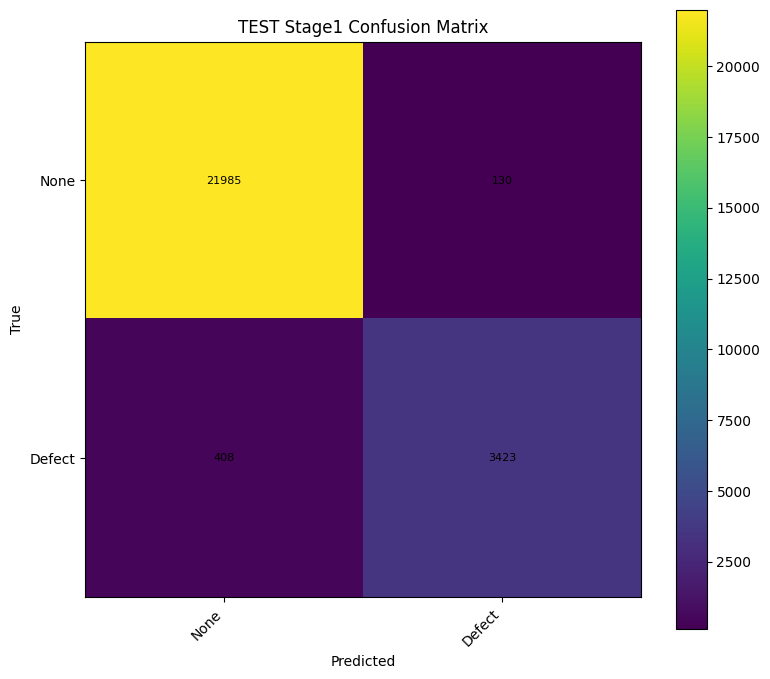


=== TEST Stage2 Report (defect-only) ===
              precision    recall  f1-score   support

      Center     0.9375    0.9189    0.9281       604
       Donut     0.6142    0.9286    0.7393        84
    Edge-loc     0.8234    0.7929    0.8079       647
   Edge-ring     0.9940    0.9372    0.9648      1417
         Loc     0.8109    0.5284    0.6399       422
      Random     0.6164    0.7903    0.6926       124
     Scratch     0.3555    0.8922    0.5084       102
   Near-Full     0.4000    0.9565    0.5641        23

    accuracy                         0.8495      3423
   macro avg     0.6940    0.8431    0.7306      3423
weighted avg     0.8832    0.8495    0.8569      3423



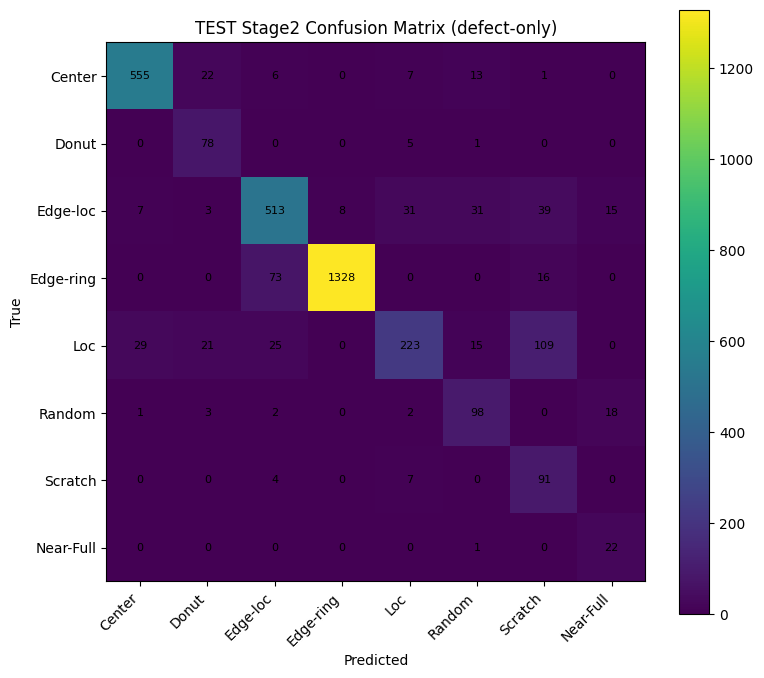


=== TEST Two-Stage Final Report (K+1) ===
              precision    recall  f1-score   support

        None     0.9818    0.9941    0.9879     22115
      Center     0.9375    0.8605    0.8973       645
       Donut     0.6142    0.9286    0.7393        84
    Edge-loc     0.8234    0.6585    0.7318       779
   Edge-ring     0.9940    0.9146    0.9527      1452
         Loc     0.8109    0.4137    0.5479       539
      Random     0.6164    0.7538    0.6782       130
     Scratch     0.3555    0.5084    0.4184       179
   Near-Full     0.4000    0.9565    0.5641        23

   micro avg     0.9642    0.9594    0.9618     25946
   macro avg     0.7260    0.7765    0.7242     25946
weighted avg     0.9652    0.9594    0.9602     25946



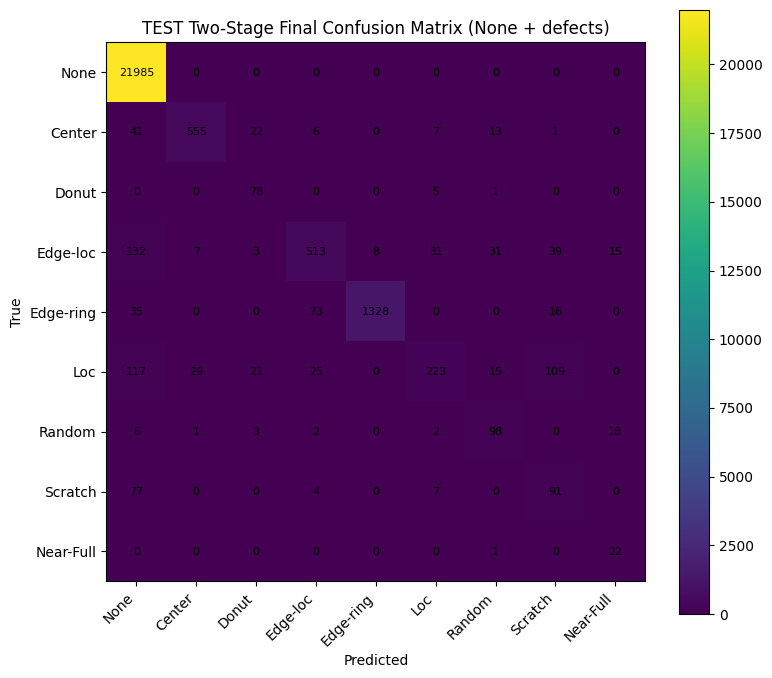


Done.


In [13]:

# =========================================================
# 9) TEST evaluation + confusion matrices
# =========================================================
print("\n==============================")
print("TEST Evaluation")
print("==============================")

has_true = any(t != "" for t in true_folder)
if has_true:
    # -----------------------------
    # A) Stage1 evaluation (None vs Defect)
    # -----------------------------
    y_true_s1 = np.array([0 if t == NONE_CLASS_NAME else 1 for t in true_folder], dtype=int)
    y_pred_s1 = np.array([0 if p == "None" else 1 for p in stage1_pred], dtype=int)

    print("\n=== TEST Stage1 Report ===")
    print(classification_report(y_true_s1, y_pred_s1, target_names=["None", "Defect"], digits=4))

    cm1 = confusion_matrix(y_true_s1, y_pred_s1, labels=[0, 1])
    plot_cm(cm1, ["None", "Defect"], "TEST Stage1 Confusion Matrix")

    # -----------------------------
    # B) Stage2 evaluation (defect-only)
    #     Only evaluate samples whose true class is defect and stage2_pred is not skipped
    # -----------------------------
    df2 = df_out[
        (df_out["true_folder"] != "") &
        (df_out["true_folder"] != NONE_CLASS_NAME) &
        (df_out["stage2_pred"] != "(skipped)")
    ].copy()

    if len(df2) > 0:
        labels_s2 = DEFECT_CLASS_LIST[:]  # fixed order
        y_true_s2 = df2["true_folder"].astype(str)
        y_pred_s2 = df2["stage2_pred"].astype(str).where(df2["stage2_pred"].isin(labels_s2), other="__other__")
        labels_plot = labels_s2 + (["__other__"] if "__other__" in y_pred_s2.values else [])

        print("\n=== TEST Stage2 Report (defect-only) ===")
        # NOTE: if some classes have 0 predicted, sklearn warns; that's expected
        print(classification_report(y_true_s2, y_pred_s2, labels=labels_plot, digits=4, zero_division=0))

        cm2 = confusion_matrix(y_true_s2, y_pred_s2, labels=labels_plot)
        plot_cm(cm2, labels_plot, "TEST Stage2 Confusion Matrix (defect-only)")
    else:
        print("\n[Stage2] No defect-only samples found to compute Stage2 confusion matrix.")

    # -----------------------------
    # C) Final K+1 evaluation (None + defects)
    # -----------------------------
    labels_final = [NONE_CLASS_NAME] + DEFECT_CLASS_LIST[:]
    #for extra in ["__unknown_defect__", "__not_in_defect_folders__"]:
     #   if extra in df_out["final_pred"].values:
      #      labels_final.append(extra)

    y_true_final = df_out["true_folder"].astype(str)
    y_pred_final = df_out["final_pred"].astype(str).where(df_out["final_pred"].isin(labels_final), other="__other__")
    #if "__other__" in y_pred_final.values:
     #   labels_final.append("__other__")

    print("\n=== TEST Two-Stage Final Report (K+1) ===")
    print(classification_report(y_true_final, y_pred_final, labels=labels_final, digits=4, zero_division=0))

    cmf = confusion_matrix(y_true_final, y_pred_final, labels=labels_final)
    plot_cm(cmf, labels_final, "TEST Two-Stage Final Confusion Matrix (None + defects)")
else:
    print("TEST folder has no class subfolders -> skipped confusion matrices.")

print("\nDone.")
